# Paired low-light robustness evaluation

This notebook evaluates saved Models A–D on exactly the same test images under clean, mild, moderate, and severe low-light conditions. It performs no training and does not update model weights.

The corruption parameters are fixed before evaluation. Noise is generated statelessly from the test-batch index, so every checkpoint receives identical corrupted pixels. Comparisons between models are therefore paired.

In [1]:
from pathlib import Path
import gc
import json
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    top_k_accuracy_score,
)

SEED = 42
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Python: {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

Python: 3.13.15
TensorFlow: 2.20.0
GPU available: True


## Paths, checkpoints, and severity definitions

Gamma and exposure jointly darken normalized pixels. The same standard-normal noise field is reused and scaled across severities, so severity does not depend on a new random noise sample.

Severe exposure is slightly below Model C/D's training range of 0.60–0.95. This tests a small amount of extrapolation beyond the simulated training domain.

In [2]:
CLASS_NAMES = ['angry', 'happy', 'sad']
MODEL_LABELS = {
    'A': 'Model A: none',
    'B': 'Model B: geometry',
    'C': 'Model C: low light',
    'D': 'Model D: combined',
}

DRIVE_DATASET_DIR = Path('/content/drive/MyDrive/Emotions Dataset')
LOCAL_DATASET_DIR = Path('/content/emotions_dataset')
PROJECT_OUTPUT_DIR = Path('/content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs')
OUTPUT_DIR = PROJECT_OUTPUT_DIR / 'robustness_evaluation'

MODEL_PATHS = {
    'A': PROJECT_OUTPUT_DIR / 'model_a' / 'model_a_baseline.keras',
    'B': PROJECT_OUTPUT_DIR / 'model_b' / 'model_b_geometric_augmentation.keras',
    'C': PROJECT_OUTPUT_DIR / 'model_c' / 'model_c_low_light_augmentation.keras',
    'D': PROJECT_OUTPUT_DIR / 'model_d' / 'model_d_combined_augmentation.keras',
}

CONDITIONS = {
    'clean': {
        'label': 'Clean',
        'gamma': 1.00,
        'exposure': 1.00,
        'noise_stddev': 0.00,
    },
    'mild': {
        'label': 'Mild',
        'gamma': 1.20,
        'exposure': 0.85,
        'noise_stddev': 0.01,
    },
    'moderate': {
        'label': 'Moderate',
        'gamma': 1.50,
        'exposure': 0.70,
        'noise_stddev': 0.02,
    },
    'severe': {
        'label': 'Severe',
        'gamma': 1.80,
        'exposure': 0.55,
        'noise_stddev': 0.03,
    },
}

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
N_BOOTSTRAP = 2000

display(pd.DataFrame(CONDITIONS).T)

,label,gamma,exposure,noise_stddev
clean,Clean,1.0,1.0,0.0
mild,Mild,1.2,0.85,0.01
moderate,Moderate,1.5,0.7,0.02
severe,Severe,1.8,0.55,0.03


## Prepare the untouched test set

Only the original test folder is loaded. Its labels are used for evaluation, never for checkpoint selection or adaptation.

In [3]:
from google.colab import drive

drive.mount('/content/drive')

required_test_directories = [
    DRIVE_DATASET_DIR / 'test' / class_name
    for class_name in CLASS_NAMES
]
missing_test_directories = [
    path for path in required_test_directories if not path.is_dir()
]

if missing_test_directories:
    missing_text = '\n'.join(str(path) for path in missing_test_directories)
    raise FileNotFoundError(
        f"The following test folders were not found:\n{missing_text}"
    )

missing_models = [
    path for path in MODEL_PATHS.values() if not path.is_file()
]
if missing_models:
    missing_text = '\n'.join(str(path) for path in missing_models)
    raise FileNotFoundError(
        f"The following saved checkpoints were not found:\n{missing_text}"
    )

if not LOCAL_DATASET_DIR.exists():
    print('Copying the dataset from Drive to the Colab runtime...')
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
    print('Copy complete.')
else:
    print('Using the dataset already copied to the Colab runtime.')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TEST_DIR = LOCAL_DATASET_DIR / 'test'

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=CLASS_NAMES,
    shuffle=False,
)

relative_test_files = [
    str(Path(path).relative_to(TEST_DIR))
    for path in test_dataset.file_paths
]
true_labels = np.concatenate([
    np.argmax(batch_labels.numpy(), axis=1)
    for _, batch_labels in test_dataset
])

print(f"Test images: {len(true_labels)}")
print(f"Class order: {CLASS_NAMES}")

Mounted at /content/drive
Copying the dataset from Drive to the Colab runtime...
Copy complete.
Found 2278 files belonging to 3 classes.
Test images: 2278
Class order: ['angry', 'happy', 'sad']


## Build deterministic test conditions

Pixels are temporarily converted from 0–255 to 0–1. Each severity applies:

y = clip(exposure × x^gamma + noise_stddev × noise, 0, 1).

The stateless seed contains the global seed and batch index. Re-iterating a condition or evaluating another model produces the same images.

In [4]:
def apply_fixed_condition(images, batch_index, settings):
    images = tf.cast(images, tf.float32) / 255.0
    images = tf.clip_by_value(images, 0.0, 1.0)

    seed = tf.stack([
        tf.constant(SEED, dtype=tf.int64),
        tf.cast(batch_index, tf.int64),
    ])
    base_noise = tf.random.stateless_normal(
        shape=tf.shape(images),
        seed=seed,
        dtype=tf.float32,
    )

    corrupted = (
        settings['exposure'] * tf.pow(images, settings['gamma'])
        + settings['noise_stddev'] * base_noise
    )
    return tf.clip_by_value(corrupted, 0.0, 1.0) * 255.0


def make_condition_dataset(settings):
    def transform(batch_index, batch):
        images, labels = batch
        corrupted_images = apply_fixed_condition(
            images,
            batch_index,
            settings,
        )
        return corrupted_images, labels

    return (
        test_dataset
        .enumerate()
        .map(
            transform,
            num_parallel_calls=tf.data.AUTOTUNE,
            deterministic=True,
        )
        .prefetch(tf.data.AUTOTUNE)
    )


condition_datasets = {
    condition_name: make_condition_dataset(settings)
    for condition_name, settings in CONDITIONS.items()
}

## Inspect the severity ladder

Every column follows one test image from clean through severe corruption. Faces should darken progressively without leaving the valid pixel range.

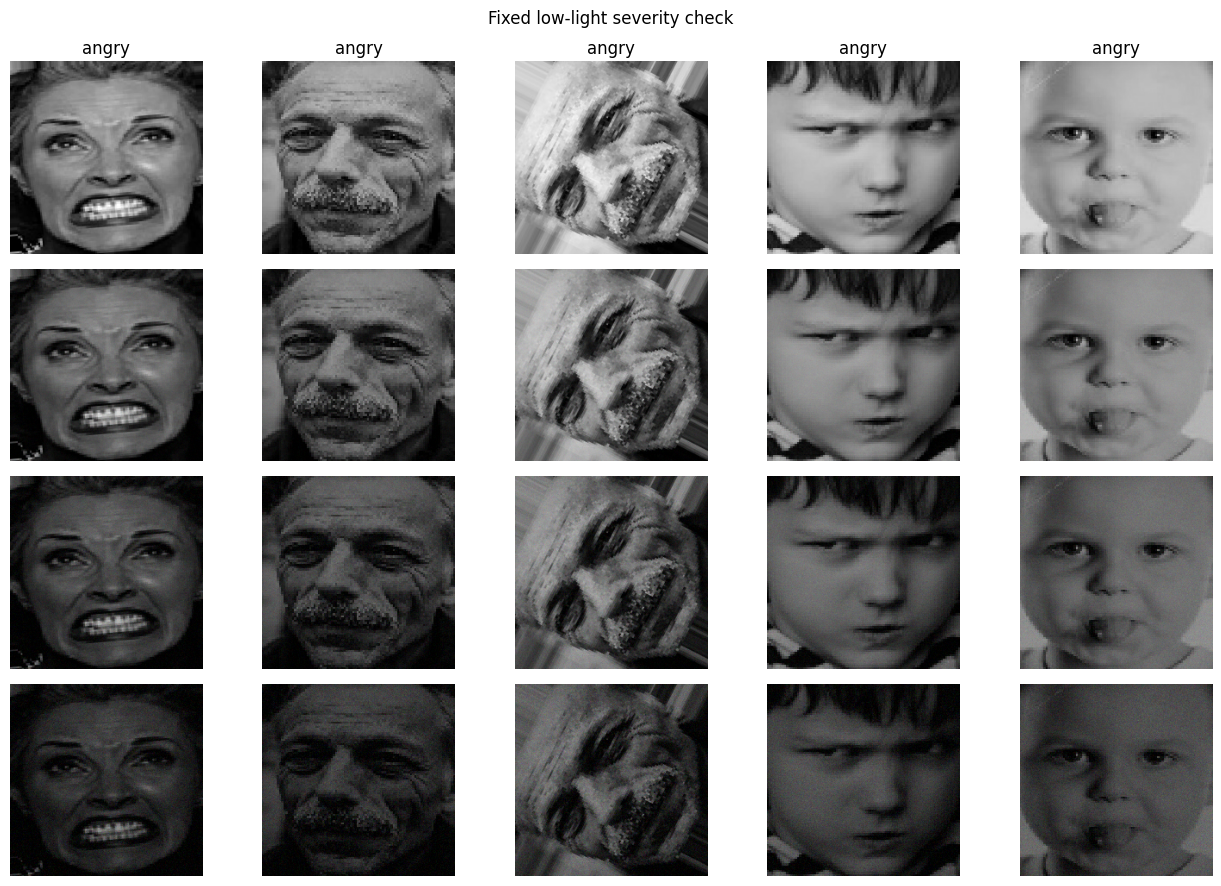

In [5]:
sample_images, sample_labels = next(iter(test_dataset))
sample_images = sample_images[:5]
sample_labels = sample_labels[:5]

fig, axes = plt.subplots(
    len(CONDITIONS),
    len(sample_images),
    figsize=(13, 9),
)

for row, (condition_name, settings) in enumerate(CONDITIONS.items()):
    condition_images = apply_fixed_condition(
        sample_images,
        tf.constant(0, dtype=tf.int64),
        settings,
    )

    for column in range(len(sample_images)):
        image = condition_images[column].numpy().astype('uint8')
        axes[row, column].imshow(image)
        axes[row, column].axis('off')

        if row == 0:
            label_index = int(tf.argmax(sample_labels[column]))
            axes[row, column].set_title(CLASS_NAMES[label_index])

    axes[row, 0].set_ylabel(settings['label'], fontsize=12)

fig.suptitle('Fixed low-light severity check')
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / 'severity_preview.png',
    dpi=200,
    bbox_inches='tight',
)
plt.show()

## Evaluate every checkpoint

Each model is loaded once and used for prediction on all four conditions. Models B and D contain geometric augmentation layers, but those layers are inactive during predict. No checkpoint is compiled, trained, or adapted here.

In [6]:
metric_rows = []
per_class_rows = []
prediction_frames = []
predictions_by_key = {}

model_order = list(MODEL_PATHS)
condition_order = list(CONDITIONS)

for model_key, model_path in MODEL_PATHS.items():
    print(f"\nLoading {MODEL_LABELS[model_key]}")
    model = tf.keras.models.load_model(
        str(model_path),
        compile=False,
    )

    for severity_index, condition_name in enumerate(condition_order):
        settings = CONDITIONS[condition_name]
        print(f"  Evaluating {settings['label']}...")
        probabilities = model.predict(
            condition_datasets[condition_name],
            verbose=0,
        )
        predicted_labels = np.argmax(probabilities, axis=1)
        predictions_by_key[(model_key, condition_name)] = predicted_labels.copy()

        report = classification_report(
            true_labels,
            predicted_labels,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )

        metric_rows.append({
            'model': model_key,
            'model_label': MODEL_LABELS[model_key],
            'condition': condition_name,
            'condition_label': settings['label'],
            'severity_index': severity_index,
            'gamma': settings['gamma'],
            'exposure': settings['exposure'],
            'noise_stddev': settings['noise_stddev'],
            'cross_entropy': float(log_loss(
                true_labels,
                probabilities,
                labels=np.arange(len(CLASS_NAMES)),
            )),
            'accuracy': float(accuracy_score(
                true_labels,
                predicted_labels,
            )),
            'top_2_accuracy': float(top_k_accuracy_score(
                true_labels,
                probabilities,
                k=2,
                labels=np.arange(len(CLASS_NAMES)),
            )),
            'macro_f1': float(f1_score(
                true_labels,
                predicted_labels,
                average='macro',
            )),
            'weighted_f1': float(f1_score(
                true_labels,
                predicted_labels,
                average='weighted',
            )),
        })

        for class_name in CLASS_NAMES:
            class_result = report[class_name]
            per_class_rows.append({
                'model': model_key,
                'condition': condition_name,
                'class': class_name,
                'precision': float(class_result['precision']),
                'recall': float(class_result['recall']),
                'f1': float(class_result['f1-score']),
                'support': int(class_result['support']),
            })

        prediction_frame = pd.DataFrame({
            'model': model_key,
            'condition': condition_name,
            'file': relative_test_files,
            'true_label': [
                CLASS_NAMES[index] for index in true_labels
            ],
            'predicted_label': [
                CLASS_NAMES[index] for index in predicted_labels
            ],
        })
        for class_index, class_name in enumerate(CLASS_NAMES):
            prediction_frame[f'prob_{class_name}'] = (
                probabilities[:, class_index]
            )
        prediction_frames.append(prediction_frame)

    del model
    tf.keras.backend.clear_session()
    gc.collect()

metrics_table = pd.DataFrame(metric_rows)
per_class_table = pd.DataFrame(per_class_rows)
all_predictions = pd.concat(prediction_frames, ignore_index=True)

accuracy_table = (
    metrics_table
    .pivot(index='model', columns='condition', values='accuracy')
    .reindex(index=model_order, columns=condition_order)
)
macro_f1_table = (
    metrics_table
    .pivot(index='model', columns='condition', values='macro_f1')
    .reindex(index=model_order, columns=condition_order)
)

print('\nAccuracy')
display(accuracy_table.style.format('{:.4f}'))
print('Macro-F1')
display(macro_f1_table.style.format('{:.4f}'))


Loading Model A: none
  Evaluating Clean...
  Evaluating Mild...
  Evaluating Moderate...
  Evaluating Severe...

Loading Model B: geometry
  Evaluating Clean...
  Evaluating Mild...
  Evaluating Moderate...
  Evaluating Severe...

Loading Model C: low light
  Evaluating Clean...
  Evaluating Mild...
  Evaluating Moderate...
  Evaluating Severe...

Loading Model D: combined
  Evaluating Clean...
  Evaluating Mild...
  Evaluating Moderate...
  Evaluating Severe...

Accuracy


condition,clean,mild,moderate,severe
model,,,,
A,0.8169,0.8139,0.7796,0.7142
B,0.7805,0.7608,0.7621,0.6971
C,0.8161,0.8231,0.8288,0.7687
D,0.7823,0.7757,0.7968,0.7384


Macro-F1


condition,clean,mild,moderate,severe
model,,,,
A,0.8028,0.8001,0.7636,0.6931
B,0.7550,0.7365,0.7421,0.6843
C,0.7997,0.8063,0.8132,0.7494
D,0.7569,0.7515,0.7755,0.7201


## Compare degradation across severity

Absolute scores are plotted rather than rescaling every model to its own clean score. This keeps clean performance and robustness visible together.

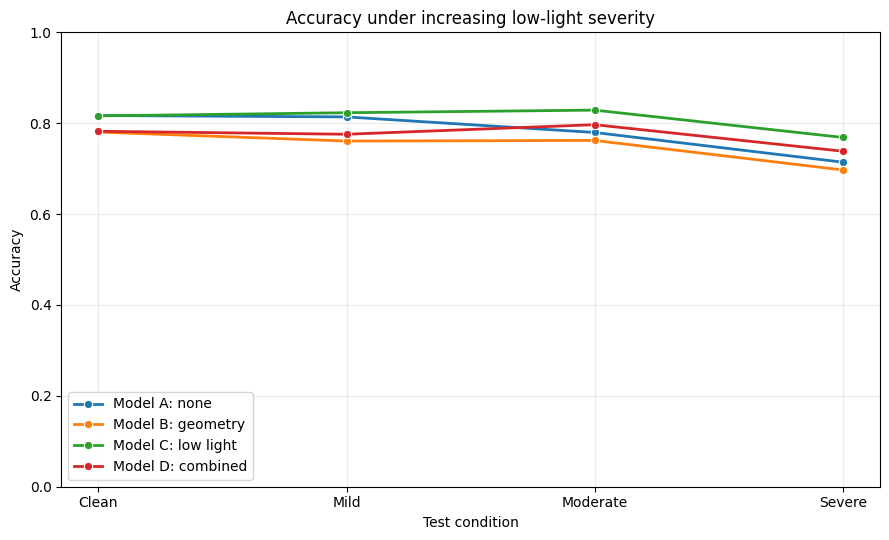

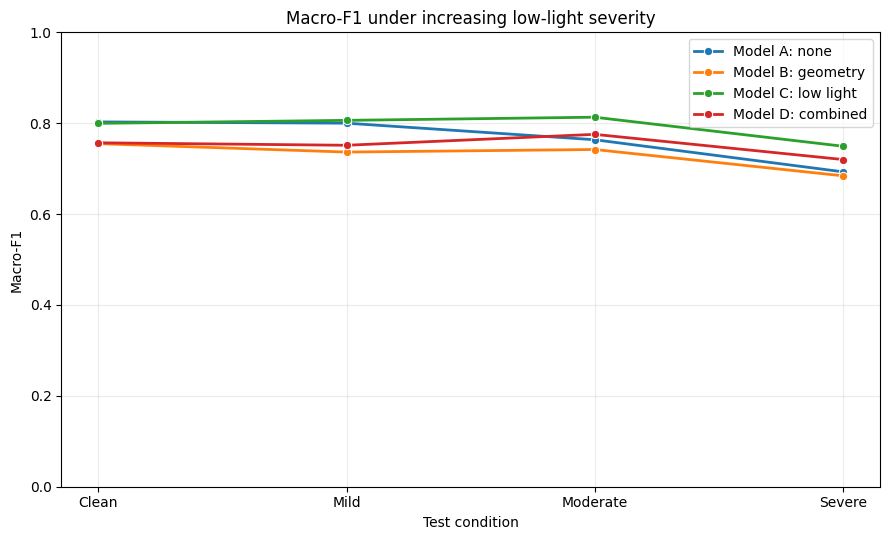

In [7]:
plot_specs = [
    ('accuracy', 'Accuracy', 'accuracy_by_severity.png'),
    ('macro_f1', 'Macro-F1', 'macro_f1_by_severity.png'),
]

for metric_name, y_label, file_name in plot_specs:
    plt.figure(figsize=(9, 5.5))
    sns.lineplot(
        data=metrics_table,
        x='severity_index',
        y=metric_name,
        hue='model_label',
        hue_order=[MODEL_LABELS[key] for key in model_order],
        marker='o',
        linewidth=2,
    )
    plt.xticks(
        range(len(condition_order)),
        [CONDITIONS[name]['label'] for name in condition_order],
    )
    plt.ylim(0, 1)
    plt.xlabel('Test condition')
    plt.ylabel(y_label)
    plt.title(f'{y_label} under increasing low-light severity')
    plt.grid(alpha=0.25)
    plt.legend(title='')
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / file_name,
        dpi=200,
        bbox_inches='tight',
    )
    plt.show()

In [8]:
summary_rows = []

for model_key in model_order:
    model_metrics = (
        metrics_table[metrics_table['model'] == model_key]
        .set_index('condition')
    )
    corrupted_metrics = model_metrics.loc[
        ['mild', 'moderate', 'severe']
    ]

    summary_rows.append({
        'model': model_key,
        'model_label': MODEL_LABELS[model_key],
        'clean_accuracy': float(
            model_metrics.loc['clean', 'accuracy']
        ),
        'mean_corrupted_accuracy': float(
            corrupted_metrics['accuracy'].mean()
        ),
        'severe_accuracy': float(
            model_metrics.loc['severe', 'accuracy']
        ),
        'clean_to_severe_accuracy_drop': float(
            model_metrics.loc['clean', 'accuracy']
            - model_metrics.loc['severe', 'accuracy']
        ),
        'clean_macro_f1': float(
            model_metrics.loc['clean', 'macro_f1']
        ),
        'mean_corrupted_macro_f1': float(
            corrupted_metrics['macro_f1'].mean()
        ),
        'severe_macro_f1': float(
            model_metrics.loc['severe', 'macro_f1']
        ),
    })

robustness_summary = (
    pd.DataFrame(summary_rows)
    .sort_values('mean_corrupted_accuracy', ascending=False)
    .reset_index(drop=True)
)

display(robustness_summary.style.format({
    'clean_accuracy': '{:.4f}',
    'mean_corrupted_accuracy': '{:.4f}',
    'severe_accuracy': '{:.4f}',
    'clean_to_severe_accuracy_drop': '{:.4f}',
    'clean_macro_f1': '{:.4f}',
    'mean_corrupted_macro_f1': '{:.4f}',
    'severe_macro_f1': '{:.4f}',
}))

,model,model_label,clean_accuracy,mean_corrupted_accuracy,severe_accuracy,clean_to_severe_accuracy_drop,clean_macro_f1,mean_corrupted_macro_f1,severe_macro_f1
0,C,Model C: low light,0.8161,0.8068,0.7687,0.0474,0.7997,0.7896,0.7494
1,D,Model D: combined,0.7823,0.7703,0.7384,0.0439,0.7569,0.7490,0.7201
2,A,Model A: none,0.8169,0.7692,0.7142,0.1027,0.8028,0.7523,0.6931
3,B,Model B: geometry,0.7805,0.7400,0.6971,0.0834,0.7550,0.7210,0.6843


## Normalized confusion matrices

Rows are true classes and columns are predicted classes. Row normalization makes class-specific degradation comparable despite unequal class counts.

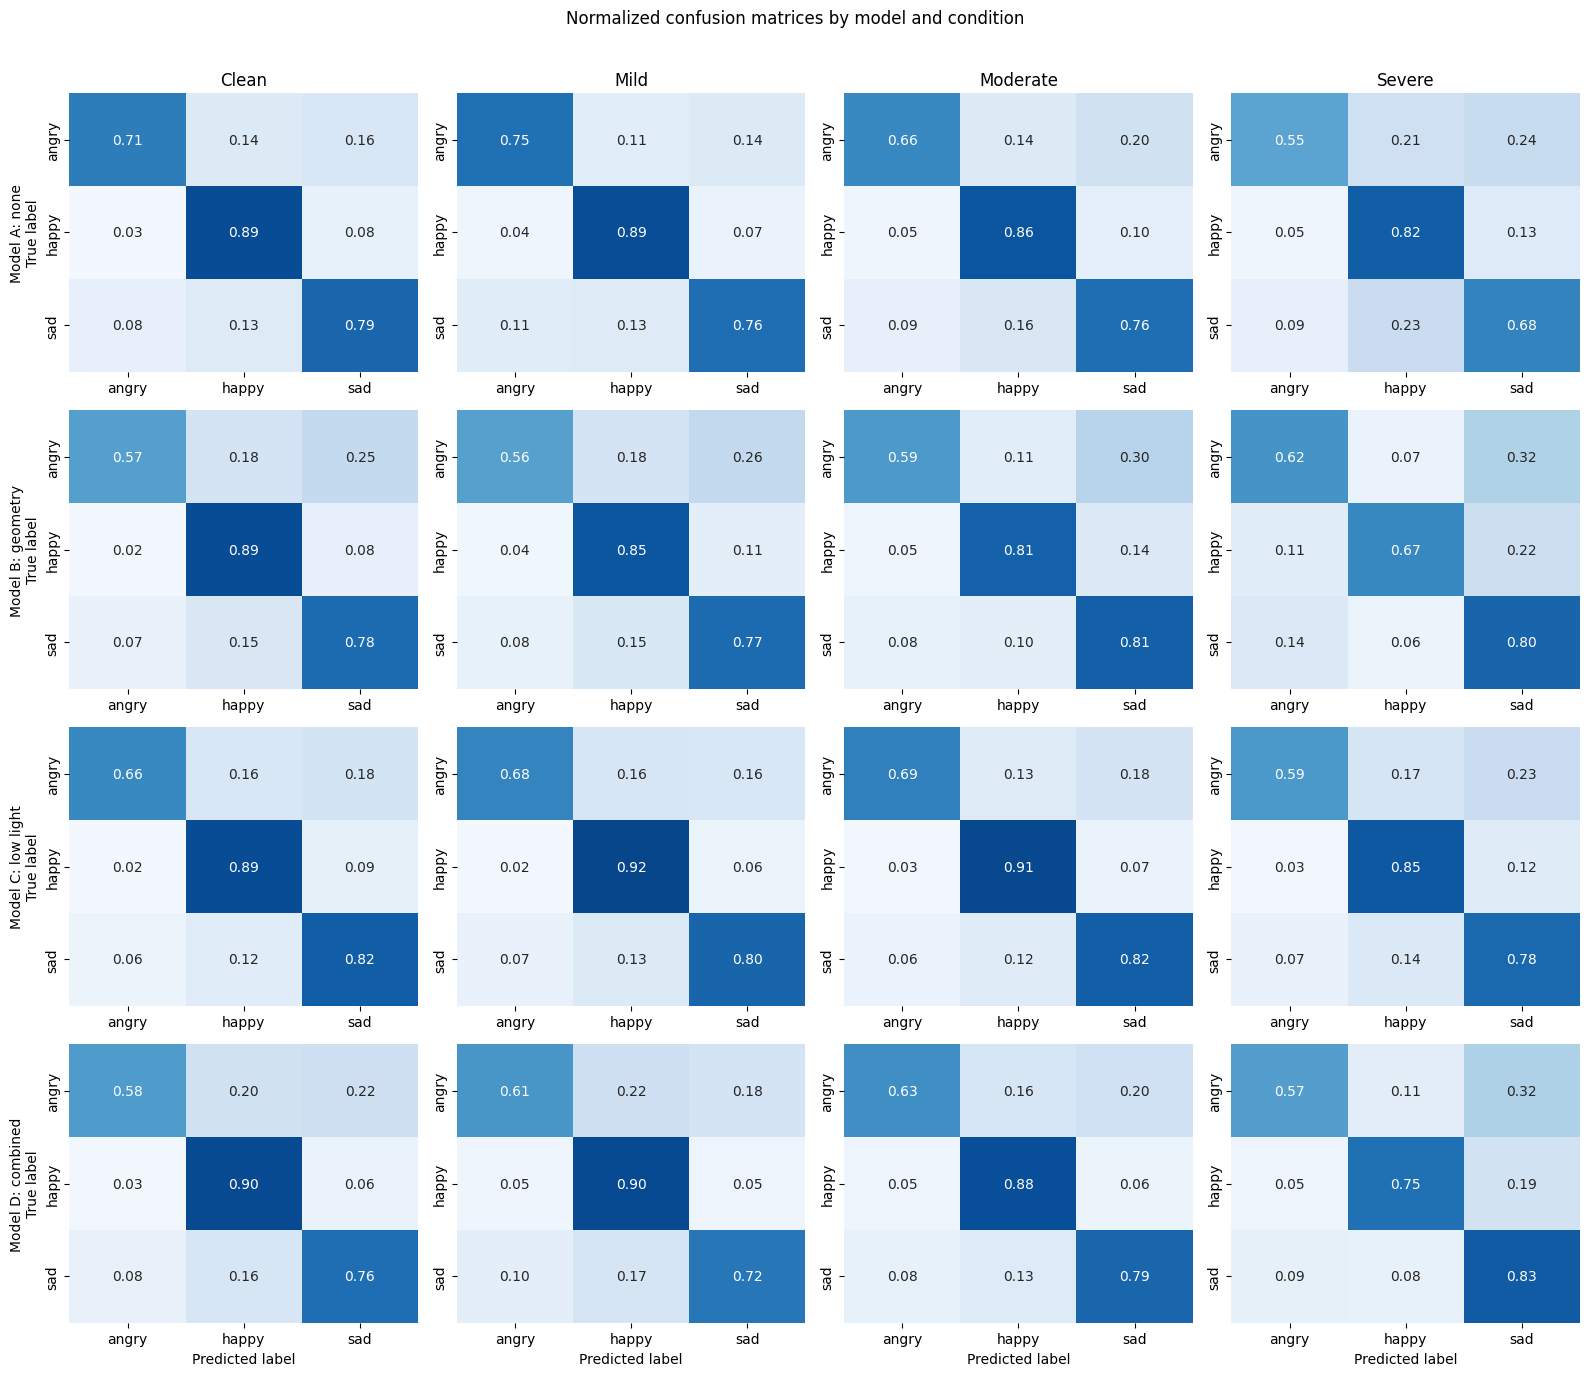

In [9]:
fig, axes = plt.subplots(
    len(model_order),
    len(condition_order),
    figsize=(16, 14),
)

for model_index, model_key in enumerate(model_order):
    for condition_index, condition_name in enumerate(condition_order):
        matrix = confusion_matrix(
            true_labels,
            predictions_by_key[(model_key, condition_name)],
            labels=np.arange(len(CLASS_NAMES)),
            normalize='true',
        )

        axis = axes[model_index, condition_index]
        sns.heatmap(
            matrix,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            vmin=0,
            vmax=1,
            cbar=False,
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axis,
        )

        if model_index == 0:
            axis.set_title(CONDITIONS[condition_name]['label'])
        if condition_index == 0:
            axis.set_ylabel(
                f"{MODEL_LABELS[model_key]}\nTrue label"
            )
        else:
            axis.set_ylabel('')
        if model_index == len(model_order) - 1:
            axis.set_xlabel('Predicted label')
        else:
            axis.set_xlabel('')

fig.suptitle('Normalized confusion matrices by model and condition')
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(
    OUTPUT_DIR / 'normalized_confusion_matrices.png',
    dpi=200,
    bbox_inches='tight',
)
plt.show()

## Paired accuracy differences

C−A isolates low-light augmentation without geometry. D−B isolates it with geometry. A paired bootstrap gives a 95% confidence interval because predictions correspond to the same test images.

These intervals describe finite-test-sample uncertainty only. They do not replace repeating model training with multiple seeds.

In [10]:
comparison_pairs = [
    ('C', 'A', 'Low light effect without geometry'),
    ('D', 'B', 'Low light effect with geometry'),
]
bootstrap_rows = []

for comparison_index, (
    treatment_model,
    control_model,
    comparison_label,
) in enumerate(comparison_pairs):
    for condition_index, condition_name in enumerate(condition_order):
        treatment_correct = (
            predictions_by_key[(treatment_model, condition_name)]
            == true_labels
        ).astype(np.float32)
        control_correct = (
            predictions_by_key[(control_model, condition_name)]
            == true_labels
        ).astype(np.float32)
        paired_differences = treatment_correct - control_correct

        rng = np.random.default_rng(
            SEED + 100 * comparison_index + condition_index
        )
        bootstrap_indices = rng.integers(
            0,
            len(true_labels),
            size=(N_BOOTSTRAP, len(true_labels)),
            dtype=np.int32,
        )
        bootstrap_differences = (
            paired_differences[bootstrap_indices].mean(axis=1)
        )

        bootstrap_rows.append({
            'comparison': comparison_label,
            'treatment': treatment_model,
            'control': control_model,
            'condition': condition_name,
            'accuracy_difference': float(
                paired_differences.mean()
            ),
            'ci_95_lower': float(
                np.quantile(bootstrap_differences, 0.025)
            ),
            'ci_95_upper': float(
                np.quantile(bootstrap_differences, 0.975)
            ),
        })

paired_accuracy_differences = pd.DataFrame(bootstrap_rows)
display(paired_accuracy_differences.style.format({
    'accuracy_difference': '{:+.4f}',
    'ci_95_lower': '{:+.4f}',
    'ci_95_upper': '{:+.4f}',
}))

,comparison,treatment,control,condition,accuracy_difference,ci_95_lower,ci_95_upper
0,Low light effect without geometry,C,A,clean,-0.0009,-0.0123,+0.0110
1,Low light effect without geometry,C,A,mild,+0.0092,-0.0040,+0.0219
2,Low light effect without geometry,C,A,moderate,+0.0492,+0.0342,+0.0645
3,Low light effect without geometry,C,A,severe,+0.0544,+0.0377,+0.0707
4,Low light effect with geometry,D,B,clean,+0.0018,-0.0110,+0.0141
5,Low light effect with geometry,D,B,mild,+0.0149,+0.0004,+0.0290
6,Low light effect with geometry,D,B,moderate,+0.0347,+0.0206,+0.0500
7,Low light effect with geometry,D,B,severe,+0.0413,+0.0250,+0.0579


## Save the complete evaluation

The long-format prediction file preserves every model-condition prediction for later error analysis without another inference run.

In [11]:
metrics_table.to_csv(
    OUTPUT_DIR / 'metrics_by_condition.csv',
    index=False,
)
per_class_table.to_csv(
    OUTPUT_DIR / 'per_class_metrics.csv',
    index=False,
)
all_predictions.to_csv(
    OUTPUT_DIR / 'predictions_all_conditions.csv',
    index=False,
)
robustness_summary.to_csv(
    OUTPUT_DIR / 'robustness_summary.csv',
    index=False,
)
paired_accuracy_differences.to_csv(
    OUTPUT_DIR / 'paired_accuracy_differences.csv',
    index=False,
)

evaluation_summary = {
    'experiment': 'Paired low-light robustness evaluation',
    'seed': SEED,
    'tensorflow_version': tf.__version__,
    'test_samples': int(len(true_labels)),
    'class_names': CLASS_NAMES,
    'model_paths': {
        key: str(path) for key, path in MODEL_PATHS.items()
    },
    'conditions': CONDITIONS,
    'noise_design': (
        'The same stateless standard-normal field is scaled '
        'across severities and reused for every model.'
    ),
    'bootstrap_replicates': N_BOOTSTRAP,
    'metrics': json.loads(
        metrics_table.to_json(orient='records')
    ),
    'robustness_summary': json.loads(
        robustness_summary.to_json(orient='records')
    ),
    'paired_accuracy_differences': json.loads(
        paired_accuracy_differences.to_json(orient='records')
    ),
}

with open(OUTPUT_DIR / 'evaluation_summary.json', 'w') as file:
    json.dump(evaluation_summary, file, indent=2)

print(f"Saved all robustness-evaluation outputs to: {OUTPUT_DIR}")

Saved all robustness-evaluation outputs to: /content/drive/MyDrive/CNN-Robustness-Low-Light-Analysis/outputs/robustness_evaluation
